In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')


In [21]:
df = pd.read_csv('Walmart.csv')

print(df.head())


   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [22]:

print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [23]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%d-%m-%Y'
)

In [25]:
df['Year'] = df['Date'].dt.year

df['Month'] = df['Date'].dt.month

df['Day'] = df['Date'].dt.day

df['Week'] = (
    df['Date']
    .dt
    .isocalendar()
    .week
    .astype(int)
)


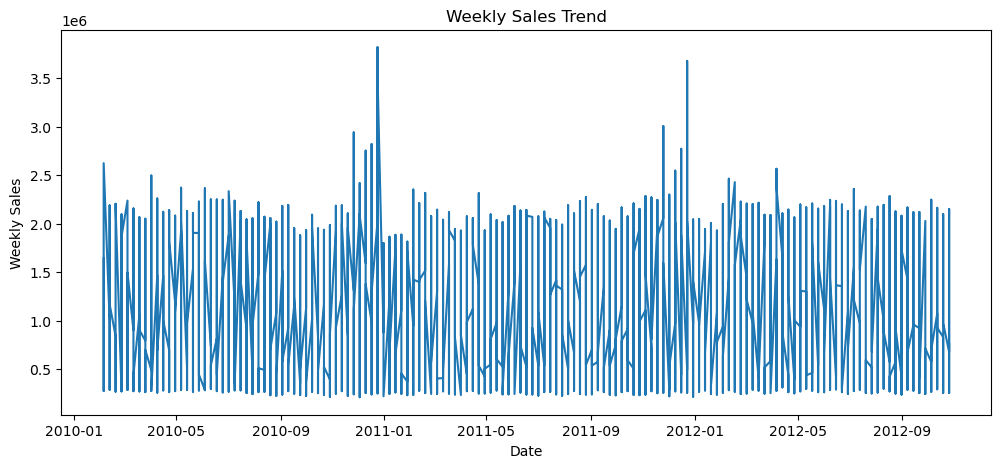

In [26]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Weekly_Sales']
)

plt.title('Weekly Sales Trend')

plt.xlabel('Date')

plt.ylabel('Weekly Sales')

plt.show()

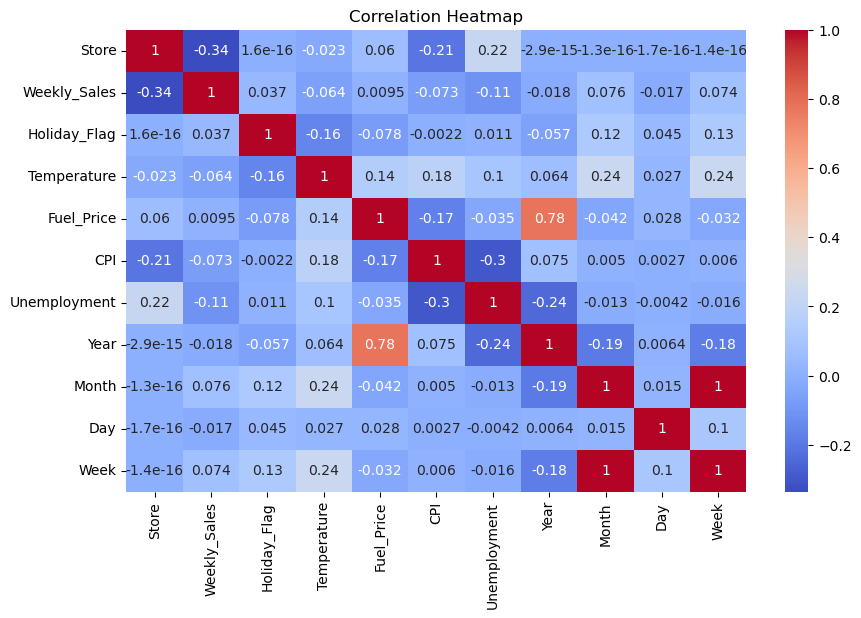

In [27]:
# =====================================================
# CORRELATION HEATMAP
# =====================================================

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

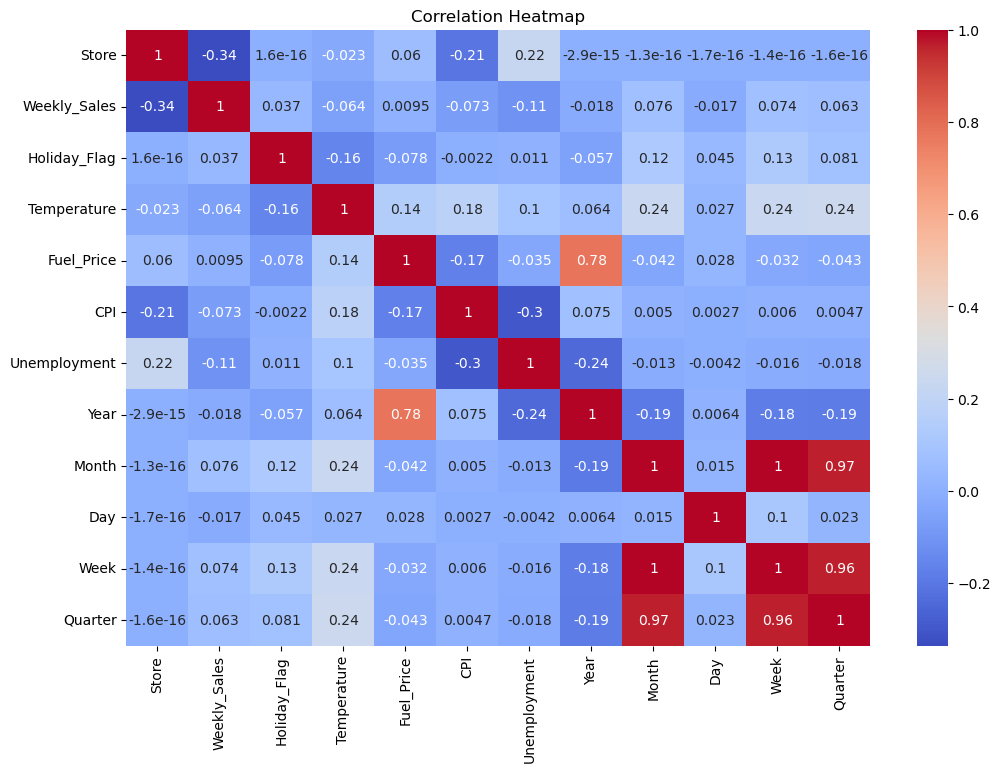

In [8]:
# =========================
# CORRELATION HEATMAP
# =========================

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [28]:
# =====================================================
# FEATURE SELECTION
# =====================================================

features = [

    'Store',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Year',
    'Month',
    'Day',
    'Week'

]

X = df[features]

y = df['Weekly_Sales']

In [30]:
# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
# =====================================================
# SAVE TRAIN DATASET
# =====================================================

train_data = X_train.copy()

train_data['Target'] = y_train.values

train_data.to_csv(
    'train_dataset.csv',
    index=False
)

In [32]:
# =====================================================
# SAVE TEST DATASET
# =====================================================

test_data = X_test.copy()

test_data['Target'] = y_test.values

test_data.to_csv(
    'test_dataset.csv',
    index=False
)

print('Train and Test datasets saved!')


Train and Test datasets saved!


In [33]:

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [34]:
joblib.dump(
    model,
    'random_forest_model.pkl'
)

print('Random Forest model saved!')


Random Forest model saved!


In [35]:
predictions = model.predict(
    X_test
)

In [36]:
# =====================================================
# EVALUATION METRICS
# =====================================================

mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

print('\nMODEL PERFORMANCE')

print('MAE :', round(mae,2))

print('MSE :', round(mse,2))

print('RMSE:', round(rmse,2))


MODEL PERFORMANCE
MAE : 54940.19
MSE : 13844863344.68
RMSE: 117664.2


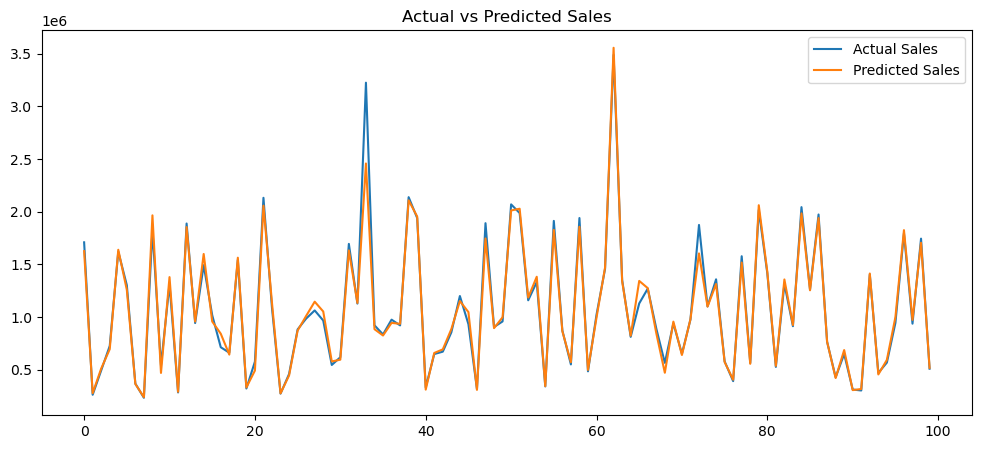

In [38]:
 #=====================================================
# ACTUAL VS PREDICTED GRAPH
# =====================================================

plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label='Actual Sales'
)

plt.plot(
    predictions[:100],
    label='Predicted Sales'
)

plt.legend()

plt.title('Actual vs Predicted Sales')

plt.show()

In [39]:
# =====================================================
# TIME SERIES FORECASTING
# =====================================================

sales_series = df.groupby(
    'Date'
)['Weekly_Sales'].sum()

sales_series = pd.to_numeric(
    sales_series,
    errors='coerce'
)

sales_series = sales_series.dropna()

In [40]:
# =====================================================
# ARIMA MODEL
# =====================================================

arima_model = ARIMA(
    sales_series,
    order=(5,1,0)
).fit()


In [41]:
# =====================================================
# SAVE ARIMA MODEL
# =====================================================

joblib.dump(
    arima_model,
    'arima_model.pkl'
)

print('ARIMA model saved!')

ARIMA model saved!


In [42]:
# =====================================================
# FUTURE FORECAST
# =====================================================

future_forecast = arima_model.forecast(
    steps=30
)

future_dates = pd.date_range(
    start=sales_series.index[-1],
    periods=30,
    freq='D'
)

forecast_df = pd.DataFrame({

    'Date': future_dates,

    'Forecasted Sales': future_forecast

})

In [43]:
# =====================================================
# SAVE FORECAST RESULTS
# =====================================================

forecast_df.to_csv(
    'forecast_results.csv',
    index=False
)

print('Forecast results saved!')

print(forecast_df.head())

Forecast results saved!
                 Date  Forecasted Sales
2012-11-02 2012-10-26      4.633711e+07
2012-11-09 2012-10-27      4.548805e+07
2012-11-16 2012-10-28      4.562473e+07
2012-11-23 2012-10-29      4.580369e+07
2012-11-30 2012-10-30      4.588700e+07


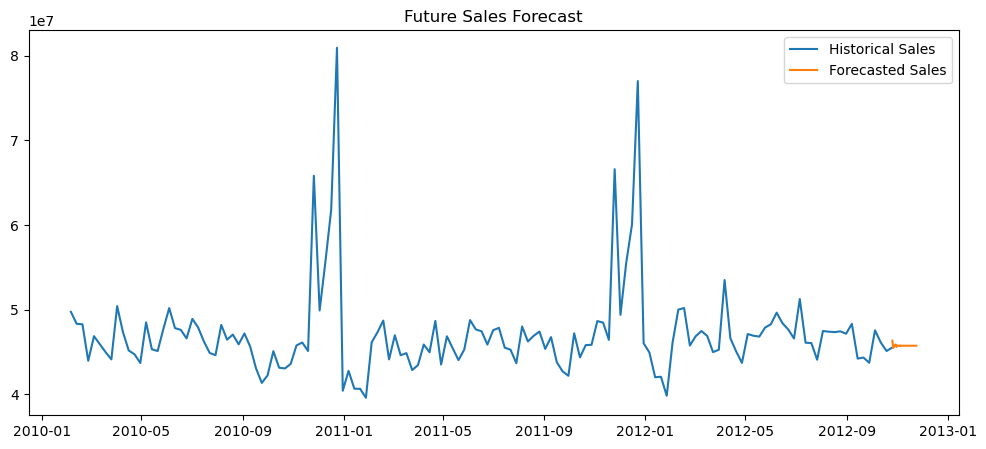

In [44]:
# =====================================================
# FORECAST GRAPH
# =====================================================

plt.figure(figsize=(12,5))

plt.plot(
    sales_series.index,
    sales_series.values,
    label='Historical Sales'
)

plt.plot(
    future_dates,
    future_forecast,
    label='Forecasted Sales'
)

plt.legend()

plt.title('Future Sales Forecast')

plt.show()
